In [1]:
import glob
import subprocess
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from concurrent.futures import ProcessPoolExecutor
import os, shutil
from tqdm import tqdm
import cv2
import warnings
warnings.filterwarnings("ignore")
from xspec import Spectrum, Model, Fit, Xset, PlotManager, Plot, AllModels, AllData, Chain, AllChains, FakeitSettings
# import acx2_xspec

In [2]:
plt.style.use("default")
plt.rc('xtick', direction='in', top=True)
plt.rc('ytick', direction='in', right=True)
plt.rc('axes', linewidth=1.15)

size = 11
plt.rc("mathtext", fontset="dejavuserif")
plt.rc('font', family='DejaVu Serif', size=size)

In [3]:
modelname = f'BKG_apec_tbabs_apec_apec_po'

Dir = '../Data/Spectra/'
bkgfile=f'Background_820_SourceSpec_00001_corr.fits'

rmf = f'background_820_RMF_00001.fits'
arf = f'background_820_ARF_00001_corr.fits'

output_dir = os.path.join(Dir, "Fitting_Results", modelname)
os.makedirs(output_dir, exist_ok=True)
# plots_dir = os.path.join(output_dir, "Plots")
# mcmc_dir = os.path.join(output_dir, "MCMC_Results")
# os.makedirs(plots_dir, exist_ok=True)
# os.makedirs(mcmc_dir, exist_ok=True)

In [4]:
Xset.xsect = 'vern'
Xset.abund = 'wilm'
Fit.statMethod = 'cstat'
Xset.chatter = 1
Xset.allowPrompting = False

 Cross Section Table set to vern:  Verner, Ferland, Korista, and Yakovlev 1996
 Solar Abundance Vector set to wilm:  Wilms, J., Allen, A. & McCray, R. ApJ 542 914 (2000) (abundances are set to zero for those elements not included in the paper).
Default fit statistic is set to: C-Statistic
   This will apply to all current and newly loaded spectra.


In [5]:
AllData.clear()

pwd = os.getcwd()
os.chdir(Dir)

sp_bkg = Spectrum(bkgfile)
sp_bkg.multiresponse[0] = rmf
sp_bkg.multiresponse[0].arf = arf
sp_bkg.multiresponse[1] = rmf
os.chdir(pwd)  # switch the current dirctory back
# sp_bkg.multiresponse[1].arf = arf

In [6]:
AllData.ignore("**-0.2,8.0-**")

In [7]:
Xset.chatter = 10
AllData.show()
Xset.chatter = 1


1 file 1 spectrum 
Spectrum 1  Spectral Data File: Background_820_SourceSpec_00001_corr.fits
Net count rate (cts/s) for Spectrum:1  1.817e+01 +/- 2.138e-01
 Assigned to Data Group 1 and Plot Group 1
  Noticed Channels:  21-796
  Telescope: eROSITA Instrument: MERGED  Channel Type: PI
  Exposure Time: 397.5 sec
 Using fit statistic: cstat
 Using Response (RMF) File            background_820_RMF_00001.fits for Source 1
 Using Auxiliary Response (ARF) File  background_820_ARF_00001_corr.fits
 Using Response (RMF) File            background_820_RMF_00001.fits for Source 2



In [8]:
AllModels.clear()
Xset.chatter = 1
m_bkg = Model("apec+TBabs(apec+apec+powerlaw)", "bkg", 1)

Xset.restore("../Data/Useful_Data/TM8_FWC_c010_mod_customized_bkg.dat")  # load fwc model from the file
m_fwc = AllModels(1, "fwc")  # point the "fwc" model from data group 1 to the variable m_fwc

# to set all parameters of fwc frozon, except the constant.
for _name in m_fwc.componentNames:
    if _name != "constant":
        _comp = m_fwc.__getattribute__(_name)
        for _pname in _comp.parameterNames:
            _par = _comp.__getattribute__(_pname)
            _par.frozen = True

tbvabs Version 2.3
Cosmic absorption with grains and H2, modified from
Wilms, Allen, & McCray, 2000, ApJ 542, 914-924
Questions: Joern Wilms
joern.wilms@sternwarte.uni-erlangen.de
joern.wilms@fau.de

http://pulsar.sternwarte.uni-erlangen.de/wilms/research/tbabs/

PLEASE NOTICE:
To get the model described by the above paper
you will also have to set the abundances:
   abund wilm

Note that this routine ignores the current cross section setting
as it always HAS to use the Verner cross sections as a baseline.

***Warning: The file sent to Xset.restore(): ../Data/Useful_Data/TM8_FWC_c010_mod_customized_bkg.dat
    is not detected to be a file generated from Xset.save().
    Xset.restore() usage is only intended for Xset.save() output.
    General XSPEC/Tcl scripts may not fully execute in PyXspec.




In [15]:
m_bkg.TBabs.nH = 0.25
# m_bkg.constant.factor= 1, -1
m_bkg.powerlaw.PhoIndex = 1.46, -1
# m_bkg.powerlaw.norm = 1e-1
m_bkg.apec.kT = 0.1
# m_bkg.apec.norm = 1.71999e-06
m_bkg.apec_3.kT = 0.25, -1
# m_bkg.apec.Abundanc.frozen = False
# m_bkg.apec_3.norm = 6.74433e-05
m_bkg.apec_4.kT = 0.6
# m_bkg.apec_4.norm = 3.03316e-07

In [16]:
Xset.chatter = 10
AllModels.show()
Xset.chatter = 1


Parameters defined:
Model bkg:apec<1> + TBabs<2>(apec<3> + apec<4> + powerlaw<5>) Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   apec       kT         keV      0.100000     +/-  1.30496E-02  
   2    1   apec       Abundanc            1.00000      frozen
   3    1   apec       Redshift            0.0          frozen
   4    1   apec       norm                2.69062E-03  +/-  2.13455E-04  
   5    2   TBabs      nH         10^22    0.250000     +/-  0.166921     
   6    3   apec       kT         keV      0.250000     frozen
   7    3   apec       Abundanc            1.00000      frozen
   8    3   apec       Redshift            0.0          frozen
   9    3   apec       norm                2.83302E-02  +/-  6.01436E-02  
  10    4   apec       kT         keV      0.600000     +/-  3.51138E-02  
  11    4   apec       Abundanc            1.00000      frozen
  12    4   apec       Redshift            0.0          frozen
  13    4   ape

In [17]:
Xset.chatter = 10
Fit.query = "yes"
Fit.nIterations = 1000
Fit.perform()
Xset.chatter = 1

                                   Parameters
C-Statistic  |beta|/N    Lvl      bkg:1:kT    bkg:4:norm      bkg:5:nH    bkg:9:norm     bkg:10:kT   bkg:13:norm   bkg:15:norm  fwc:1:factor
1016.62      13509.5      -3      0.436382   0.000640457      0.378058    0.00642774      0.932787    0.00289406    0.00899484       1.17621
887.432      3918.42      -4      0.217135    0.00145205      0.300458   0.000245448      0.651956    0.00270029     0.0112703       1.20165
855.762      3682.14      -5      0.207090    0.00244377      0.388243   0.000113184      0.802415    0.00329956     0.0118531       1.17124
854.275      3576.46      -2      0.214106    0.00241669      0.443432   3.19933e-05      0.710700    0.00465366     0.0120616       1.17062
848.882      3119.59      -3      0.215771    0.00259571      0.512016   9.25573e-06      0.731585    0.00618319     0.0123380       1.16497
842.164      2884.24      -4      0.217583    0.00262914      0.571106   3.37514e-06      0.722876    0.0076

In [18]:
stat = Fit.statistic
dof = Fit.dof
stat/dof

1.0677374833559388

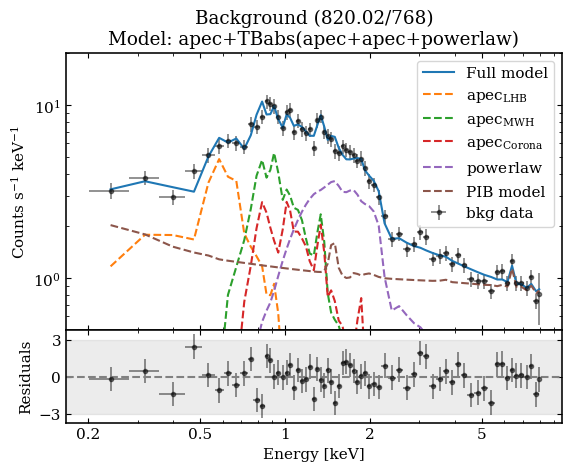

In [19]:
Plot.device = "/null"
Plot.add = True
Plot.xAxis = "keV"
Plot.setRebin(minSig=10, maxBins=30)
Plot('ldata delchi')
total_model = Plot.model(1)
bkg_data = Plot.y(1)
bkg_data_err = Plot.yErr(1)
eng_bkg= Plot.x(1)
eng_bkg_err = Plot.xErr(1)
res_bkg = Plot.y(1,2)
res_bkg_err = Plot.yErr(1,2)
Pib_model = np.zeros(len(Plot.model(1)))
for i in range(5, Plot.nAddComps()+1):
    Pib_model += np.array(Plot.addComp(i, 1))

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [3, 1], 'hspace': 0})

# Plot the data and models
ax1.errorbar(eng_bkg, bkg_data, xerr=eng_bkg_err, yerr=bkg_data_err, fmt='.', color="black", label="bkg data", alpha=0.5, lw=1.2)
ax1.plot(eng_bkg, total_model, label="Full model")
ax1.plot(eng_bkg, Plot.addComp(1, 1), label=r"$\mathrm{apec_{LHB}}$", linestyle="--")
ax1.plot(eng_bkg, Plot.addComp(2, 1), label=r"$\mathrm{apec_{MWH}}$", linestyle="--")
ax1.plot(eng_bkg, Plot.addComp(3, 1), label=r"$\mathrm{apec_{Corona}}$", linestyle="--")
ax1.plot(eng_bkg, Plot.addComp(4, 1), label=r"$\mathrm{powerlaw}$", linestyle="--")
# ax1.plot(eng_bkg, Plot.addComp(3, 1), label=r"$\mathrm{powerlaw}$", linestyle="--")
ax1.plot(eng_bkg, Pib_model, label="PIB model", linestyle="--")
ax1.set_yscale("log")
ax1.set_xscale("log")
ax1.set_ylabel(r"$\mathrm{Counts\ s^{-1}\ keV^{-1}}$")
ax1.set_ylim(0.5, 2e1)
ax1.legend(loc="upper right")

# Plot the residuals
residuals = np.array(bkg_data) - np.array(total_model)
ax2.errorbar(eng_bkg, res_bkg, xerr=eng_bkg_err, yerr=res_bkg_err, fmt='.', color="black", label="residuals", alpha=0.5, lw=1.2)
ax2.axhline(0, color='gray', linestyle='--')
ax2.set_xscale("log")
ax2.set_xlabel("Energy [keV]")
ax2.set_ylabel("Residuals")
ax2.set_xticks([0.2, 0.5, 1, 2, 5])
ax2.set_xticklabels(['0.2', '0.5', '1', '2', '5'])
# ax2.set_ylim(-5, 5)
ax2.set_yticks([-3, 0, 3])
ax2.axhspan(-3, 3, color='gray', alpha=0.15)
ax1.set_title(f'Background ({stat:.2f}/{dof})\nModel: apec+TBabs(apec+apec+powerlaw)')
fig.savefig(f"{output_dir}/PySpec_fitting_grp.png", dpi=300, bbox_inches="tight")

In [20]:
if os.path.exists(f'{output_dir}/bkg_xspec_model.xcm'):
    os.remove(f'{output_dir}/bkg_xspec_model.xcm')
Xset.save(f'{output_dir}/bkg_xspec_model.xcm')